In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

vladislavgabaraev_temp2424_path = kagglehub.dataset_download('vladislavgabaraev/temp2424')

print('Data source import complete.')


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ, 2024</b></h3>

<h3 style="text-align: center;"><b>Семинар. Семантическая сегментация изображений </b></h3>

В этом семинаре вы научитесь сегментировать изображение на 4 класса. Мы будем работать с датасетом [Lyft Udacity Challenge](https://www.udacity.com/blog/2018/05/lyft-udacity-self-driving-hiring-challenge.html).

**План семинара:**
* Данные
  * Загрузка данных Lyft-Udacity
  * Описание данных и введение в задачу
  * Подготовка датасета

* Метрика IoU (intersection over union)
* Лоссы задачи сегментации
  * BCE loss
  * DICE
* Модель SegNet
  * Простой способ
  * Реализация через классы
  * Upsampling варианты

* Train + Validation
* Test


  



## Данные

В мае 2018 года компании Udacity и Lyft объединили усилия и создали соревнование, где каждый участник должен был создать нейронную сеть, способную помечать каждый пиксель на изображении как принадлежащий либо автомобилю, либо дороге, либо чему-то еще. Это называется **семантической сегментацией**.

В этом наборе данных представлены изображения данных и маркированные семантические сегменты, полученные с помощью симулятора самодвижущегося автомобиля CARLA.

### Загрузка данных

Скачаем датасет и распакуем:

Библиотека, позволяющая скачивать прямо с яндекс диска

In [ ]:
!pip install wldhx.yadisk-direct

Скачиваем данные прямо с яндекс идска. yadisk-direct https://disk.yandex.com/d/jJrOLbYlBYVESQ — утилита, которая преобразует публичную ссылку на Яндекс.Диск в прямую ссылку для скачивания
$(...) — подстановка: результат команды внутри скобок передаётся как аргумент
curl -L — скачивает файл по URL, следуя редиректам (-L)
-o lyft_segmentation.zip — сохраняет скачанный файл под именем lyft_segmentation.zip

In [ ]:
!curl -L $(yadisk-direct https://disk.yandex.com/d/jJrOLbYlBYVESQ) -o lyft_segmentation.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 2620M  100 2620M    0     0  20.2M      0  0:02:09  0:02:09 --:--:-- 21.8M     0  24.1M      0  0:01:48  0:00:37  0:01:11 21.0M 17.2M


### Описание данных

In [ ]:
!unzip lyft_segmentation.zip

Archive:  lyft_segmentation.zip
   creating: lyft_segmentation/
  inflating: __MACOSX/._lyft_segmentation  
  inflating: lyft_segmentation/.DS_Store  
  inflating: __MACOSX/lyft_segmentation/._.DS_Store  
   creating: lyft_segmentation/images/
   creating: lyft_segmentation/segmentation_masks/
  inflating: lyft_segmentation/images/02_02_166.png  
  inflating: __MACOSX/lyft_segmentation/images/._02_02_166.png  
  inflating: lyft_segmentation/images/F7-25.png  
  inflating: __MACOSX/lyft_segmentation/images/._F7-25.png  
  inflating: lyft_segmentation/images/06_00_208.png  
  inflating: __MACOSX/lyft_segmentation/images/._06_00_208.png  
  inflating: lyft_segmentation/images/07_00_106.png  
  inflating: __MACOSX/lyft_segmentation/images/._07_00_106.png  
  inflating: lyft_segmentation/images/07_00_112.png  
  inflating: __MACOSX/lyft_segmentation/images/._07_00_112.png  
  inflating: lyft_segmentation/images/F7-31.png  
  inflating: __MACOSX/lyft_segmentation/images/._F7-31.png  
  infla

Датасет представляет собой две папки с RGB картинками:

- images:
    - 02_00_000.png
    - 02_00_001.png
    - ...
- segmentation_masks:
    - 02_00_000.png
    - 02_00_001.png
    - ...

В папке images лежат 5000 RGB картинок, которые подаются сети на вход. В папке segmentation лежат карты сегментации к картинкам из папки images. Карта сегментации — это двумерная картинка, на которой пиксели разных классов имеют разные значения.

Давайте отрисуем картинки из датасета.


In [ ]:
import numpy as np
import pandas as pd
from PIL import Image
import os
import matplotlib.pyplot as plt
import cv2

Да, всё верно! Разберём по частям:
os.listdir(...) — возвращает список всех файлов в указанной папке. Порядок при этом не гарантирован (может быть случайным).
sorted(...) — сортирует список по алфавиту/числам (по имени файла). После sorted() оба списка будут в одинаковом порядке, и можно быть уверенным, что:

image_files[0] → image_001.png
segmentation_files[0] → mask_001.png

In [ ]:
# считаем все наименования картин в папке images и segmentation_masks
image_files = sorted(os.listdir("/kaggle/working/lyft_segmentation/images"))
segmentation_files = sorted(os.listdir("/kaggle/working/lyft_segmentation/segmentation_masks"))

In [ ]:
len(image_files)

5000

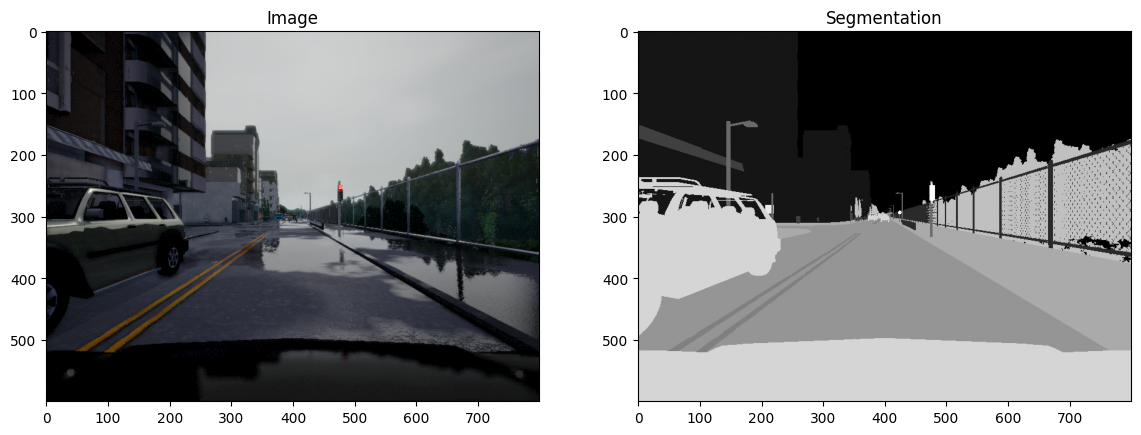

In [ ]:
# считываем картинку и ее карту сегментации
img = plt.imread(f'./lyft_segmentation/images/{image_files[0]}')
img_seg = plt.imread(f'./lyft_segmentation/segmentation_masks/{image_files[0]}')

# Создаём "холст" с двумя графиками рядом (1 строка, 2 столбца)
# figsize=(14,10) — размер всего холста в дюймах (ширина, высота)
# _ — объект figure (не нужен, поэтому игнорируем)
# axes — массив из двух "ячеек" для графиков
_, axes = plt.subplots(1,2, figsize=(14,10))
axes[0].imshow(img);
axes[0].set_title("Image")
axes[1].imshow(img_seg[..., 0], cmap='gray'); #Ключевой момент — img_seg[..., 0]:
# Маска сегментации технически хранится как RGB-изображение
# Но реальная информация (номер класса пикселя) находится только в первом канале
# ... означает "все остальные размерности" (высота, ширина), а 0 — берём первый канал
axes[1].set_title("Segmentation")

plt.show()

Как видно, на карте сегментации разными градациями серого обозначены разные классы. Давайте посмотрим, сколько всего есть различных классов. Для этого посмотрим, сколько различных значений пикселей есть на картинке:

In [ ]:
np.unique(img_seg * 255)

# Когда plt.imread() читает PNG-файл, он автоматически нормализует значения пикселей из диапазона [0, 255] в диапазон [0.0, 1.0] (float).
# Поэтому без умножения np.unique(img_seg) вернёт что-то вроде:
# [0.0, 0.00392, 0.00784, 0.01176, ...]
# Это неудобно читать.
# После * 255 получаем целые числа — реальные метки классов:

array([ 0.,  1.,  2.,  3.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.],
      dtype=float32)

Как видим, классов сегментации у нас всего 13.

Давайте заведем словарь соответствия классам номерам:

In [ ]:
labels = {
    0: 'Unlabeled',
    1: 'Building',
    2: 'Fence',
    3: 'Other',
    4: 'Pedestrian',
    5: 'Pole',
    6: 'Roadline',
    7: 'Road',
    8: 'Sidewalk',
    9: 'Vegetation',
    10: 'Car',
    11: 'Wall',
    12: 'Traffic sign'
}

Давайте для одного изображения отрисуем сегментационную маску для каждого класса по отдельности:

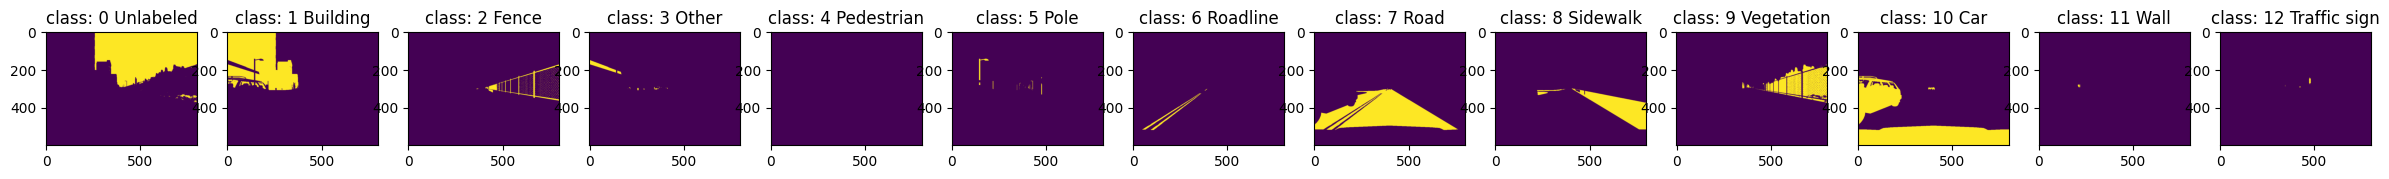

In [ ]:
_, axes = plt.subplots(1,13, figsize=(30,5))
for i in range(13):
  mask = plt.imread(f'./lyft_segmentation/segmentation_masks/{image_files[0]}') * 255

    # np.where(условие, значение_если_True, значение_если_False)
    # Где пиксель == i (текущий класс) → ставим 255 (белый)
    # Где пиксель != i               → ставим 0   (чёрный)
    # Итог: белым выделены ТОЛЬКО пиксели текущего класса
  mask = np.where(mask == i, 255, 0)
  mask = mask[:,:,0]

  axes[i].imshow(mask);
  axes[i].set_title(f'class: {i} {labels[i]}')

### Создадим датасет

Теперь создадим из этих данных датасет для обучения модели.

Для начала создадим два списка:
- список с путями до RGB картинок;
- список с путями до карт сегментаций этих картинок;

In [ ]:
images = ['./lyft_segmentation/images/' + img_name for img_name in image_files]
segmentation_masks = ['./lyft_segmentation/segmentation_masks/' + img_name for img_name in segmentation_files]

In [ ]:
images[:5], segmentation_masks[:5]

(['./lyft_segmentation/images/02_00_000.png',
  './lyft_segmentation/images/02_00_001.png',
  './lyft_segmentation/images/02_00_002.png',
  './lyft_segmentation/images/02_00_003.png',
  './lyft_segmentation/images/02_00_004.png'],
 ['./lyft_segmentation/segmentation_masks/02_00_000.png',
  './lyft_segmentation/segmentation_masks/02_00_001.png',
  './lyft_segmentation/segmentation_masks/02_00_002.png',
  './lyft_segmentation/segmentation_masks/02_00_003.png',
  './lyft_segmentation/segmentation_masks/02_00_004.png'])

Давайте вместо 13 классов остановимся на 4х классах. - НЕТ!

Теперь создадим датасет torch.utils.data.Dataset для удобной работы c нашими данными в PyTorch.

In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch
from torch import nn
from torch.nn import functional as F
from torchvision import transforms
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


Создаем класс для кастомного датасета. Давайте упростим задачу: будем сегментировать картинки только на четыре класса из представленных тринадцати:
- unlabeled;
- building;
- road;
- car.

После занятия вы самостоятельно можете попробовать решить более сложную задачу и сегментировать картинки датасета на большее количество классов.

In [ ]:
class SelfDrivingDataset(Dataset):
    def __init__(self, images, segmentation_masks):

        self.images = images
        self.segmentation_masks = segmentation_masks

        self.images_transforms = transforms.Compose([
            transforms.Resize((256, 256)), # размер каждой картинки будет приведен к 256*256
            transforms.ToTensor(), # картинка из питоновского массива переводится в формат torch.Tensor
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]) # значения пикселей картинки нормализуются
        ])

        self.masks_transforms = transforms.Compose([
            # используем InterpolationMode.NEAREST, чтобы при изменении размера
            # маски сегментации не менялись номера классов
            transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST), # размер каждой картинки будет приведен к 256*256
            transforms.ToTensor(), # картинка из питоновского массива переводится в формат torch.Tensor
        ])

    def __getitem__(self, index):
        '''
        этот метод должен по заданному номеру пары картинка-сегментация (index)
        возвращать эту пару. Этот метод обязательно нужно реализовывать во всех
        кастомных классах Dataset. Перед тем, как выдать на выходе
        пару картинка-сегментация, можно применить к картинкам любые преобразования:
        например, знакомую нам аугментацию.
        '''

        # загружаем нужные картинку и ее карту сегментации
        img = Image.open(self.images[index])
        mask = Image.open(self.segmentation_masks[index])

        # # применяем предобработку к RGB картинке
        img = self.images_transforms(img)
        # # применяем предобработку к маске сегментации
        mask = self.masks_transforms(mask)*255

        # # делим маску сегментации на 13 бинарных масок сегментации
        # # отдельно для каждого класса
        masks = []

        # вытаскиваем пиксели, принадлежащие классам
        for key in labels.keys():
            # генерируем бинарную маску сегментации для текущего класса i
            cls_mask = torch.where(mask==key, 1, 0)
            masks.append(cls_mask[0,:,:].numpy())

        masks = torch.as_tensor(masks, dtype=torch.uint8)
        # схлопываем бинарные карты сегментации в одну
        masks = torch.argmax(masks, axis=0)

        # возвращаем пару: картинка — ее маска сегментации
        return (img, masks)

    def __len__(self):
        '''
        этот метод должен возвращать количество пар картинка-сегментация в датасете
        '''
        return len(self.images)

Проверим, что наш Dataset работает. Заведем переменную датасета и возьмем нулевой элемент. Отрисуем картинку и одну из ее бинарных карт сегментации.

/tmp/ipykernel_57/716715432.py:48: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  masks = torch.as_tensor(masks, dtype=torch.uint8)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.7176471].


torch.Size([3, 256, 256]) torch.Size([256, 256])


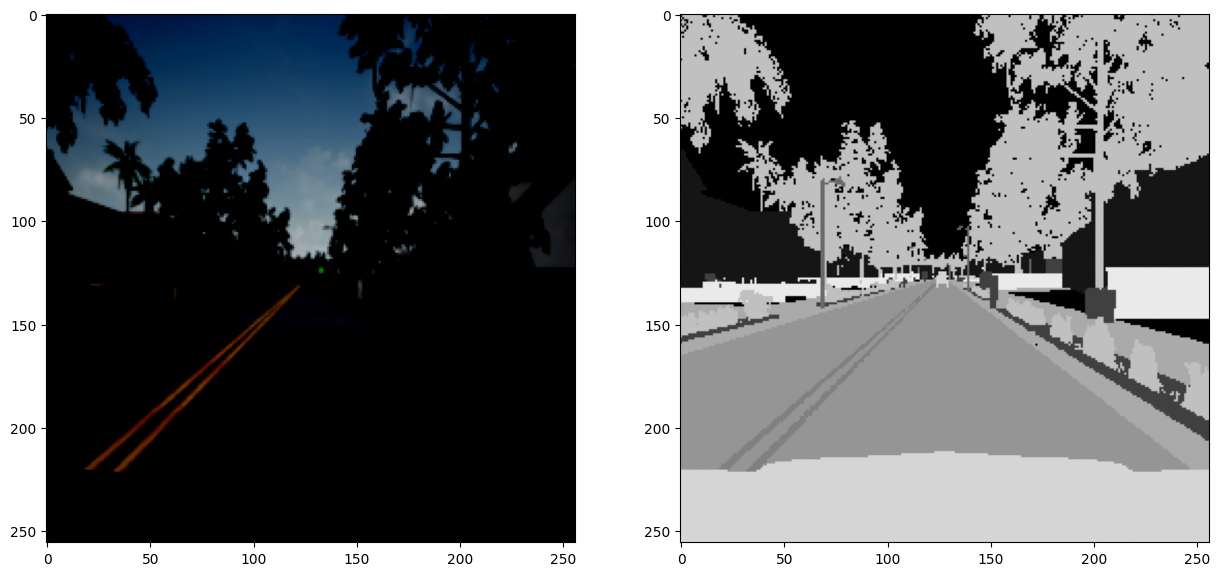

In [ ]:
dataset = SelfDrivingDataset(images, segmentation_masks)

# dataset[0] — это вызов метода __getitem__(0)
img, mask = dataset[3423]

print(img.shape, mask.shape)

# отрисовываем картинку и ее десятую маску сегментации
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(img.permute(1, 2, 0))
# показываем бинарную маску 7 класса — "road"
ax[1].imshow(mask, cmap='gray')
plt.show()

In [ ]:
mask.unique()

tensor([ 0,  1,  2,  3,  5,  6,  7,  8,  9, 10, 11, 12])

Разделим выборку на train и val:

In [ ]:
train_size = int(len(dataset) * 0.8)
val_size = len(dataset) - train_size

train_data, val_data = torch.utils.data.random_split(dataset, [train_size, val_size])

И заведем даталоадеры:

In [ ]:
train_dataloader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
valid_dataloader = torch.utils.data.DataLoader(val_data, batch_size=32, shuffle=False)

## Metric

### IoU (intersection over union)

В данном разделе предлагается использовать следующую метрику для оценки качества:

$I o U=\frac{\text {target } \cap \text { prediction }}{\text {target } \cup{prediction }}$

Пересечение (A ∩ B) состоит из пикселей, найденных как в маске предсказания, так и в основной маске истины, тогда как объединение (A ∪ B) просто состоит из всех пикселей, найденных либо в маске предсказания, либо в целевой маске.


Для примера посмотрим на истину (слева) и предсказание (справа):
![alt text](https://www.jeremyjordan.me/content/images/2018/05/target_prediction.png)


Тогда пересечение и объединение будет выглядеть так:

![alt text](https://www.jeremyjordan.me/content/images/2018/05/intersection_union.png)

Что будет являться пересением и объединением в задаче сегментации?

Давайте разберем следующий пример:





<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1rBYFgli48AUUN9idiyq8j3J5DboB93yN" width=1000 height=800/></p>

Мы можем сформулировать IoU в терминах матрицы ошибок

Чтобы проверять свои функции на корректность, давайте воспользуемся библиотекой [torchmetrics](https://lightning.ai/docs/torchmetrics/stable/classification/jaccard_index.html)

In [ ]:
!pip install torchmetrics

In [ ]:
device = 'cuda'

In [ ]:
from torchmetrics import JaccardIndex
import torch
import matplotlib.pyplot as plt
import numpy as np

jaccard = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)

In [ ]:
def iou_score(logits: torch.Tensor, labels: torch.Tensor, threshold: float = 0.5):
    # Lets compute metrics for some threshold
    # first convert mask values to probabilities, then
    # apply thresholding

    prob_mask = logits.sigmoid() #шаг 1, получаем логиты
    pred_mask = (prob_mask > threshold).float() #переводим в предсказания класса, если выше порога

    tp = torch.sum(pred_mask*labels) #если умножить класс 0 на 1 то получится 0 -> это будет только TP
    fp = torch.sum(pred_mask) - tp
    fn = torch.sum(labels) - tp

    eps = 1e-8 # to avoid 0/0
    iou = (tp + eps) / (tp + fp + fn + eps) #эпсилони добавляем, чтобы не было 0/0

    return iou

Загружаем пример из картиночек

In [ ]:
!gdown --folder 1EX0RW1TRQVkLmR1h6miCQqyhYPFyg28M

In [ ]:
path_to_dummy_samples = '/content/for_asserts'
dummpy_sample = {'logits': torch.load(f'{path_to_dummy_samples}/logits.pt'),
                 'labels': torch.load(f'{path_to_dummy_samples}/labels.pt')}
dummpy_sample['labels'] = dummpy_sample['labels'].to(device)
dummpy_sample['logits'] = dummpy_sample['logits'].to(device)

In [ ]:
print(dummpy_sample['logits'])
print(dummpy_sample['logits'].sigmoid())
print(dummpy_sample['labels'])

tensor([[[[-1.9818, -3.0264, -3.4634, -3.3669],
          [-3.3132, -3.2690,  0.0526, -3.0650],
          [-3.1722,  0.2558,  0.2902, -3.2031],
          [-3.0457, -3.0761, -3.1206, -3.1873]]]], device='cuda:0')
tensor([[[[0.1211, 0.0462, 0.0304, 0.0333],
          [0.0351, 0.0367, 0.5131, 0.0446],
          [0.0402, 0.5636, 0.5720, 0.0390],
          [0.0454, 0.0441, 0.0423, 0.0396]]]], device='cuda:0')
tensor([[[[0., 0., 0., 0.],
          [0., 1., 1., 0.],
          [0., 1., 0., 0.],
          [0., 0., 0., 0.]]]], device='cuda:0')


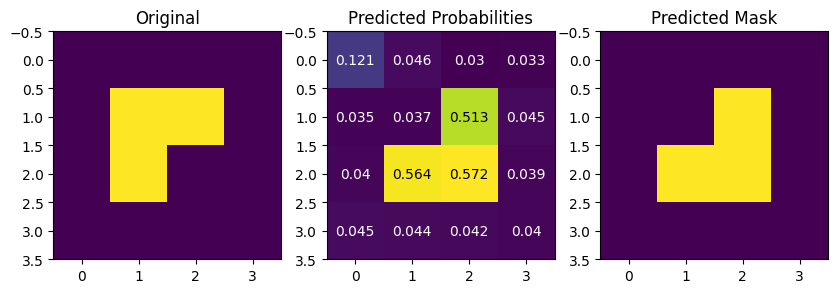

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize= (10,3*10))

# --- Левый график: оригинальная маска ---
# squeeze(1) убирает лишнее измерение, [0] берёт первый элемент батча
ax1.imshow(dummpy_sample['labels'].squeeze(1)[0].cpu())
ax1.set_title("Original")

# --- Средний график: предсказанные вероятности ---
# .sigmoid() переводит сырые logits в вероятности от 0 до 1
ax2.imshow(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu())

# Проходим по каждому пикселю и подписываем вероятность числом
for (j,i),label in np.ndenumerate(dummpy_sample['logits'].sigmoid().squeeze(1)[0].cpu()):
    if label < 0.5:
        color = 'white'
    else:
        color = 'black'
    # Рисуем число на пикселе, округляем до 3 знаков
    ax2.text(i,j,round(label,3), color=color, ha='center',va='center')

ax2.set_title("Predicted Probabilities")

ax3.imshow((dummpy_sample['logits'].sigmoid() > 0.5).squeeze(1)[0].cpu())
ax3.set_title("Predicted Mask")
plt.show()

In [ ]:
iou_ours = iou_score(dummpy_sample['logits'], dummpy_sample['labels'], threshold = 0.5)
iou_torch = jaccard(dummpy_sample['logits'], dummpy_sample['labels'])

In [ ]:
assert iou_torch == iou_ours

In [ ]:
iou_torch

tensor(0.5000, device='cuda:0')

In [ ]:
iou_ours.to('cpu')

tensor(0.5000)

## Loss

### CrossEntropy Loss

In [ ]:
loss = nn.CrossEntropyLoss()

## Model

Здесь мы с вами реализуем модель SegNet.

-----------------------------------------------------------------------------------------

# SegNet [2 балла]

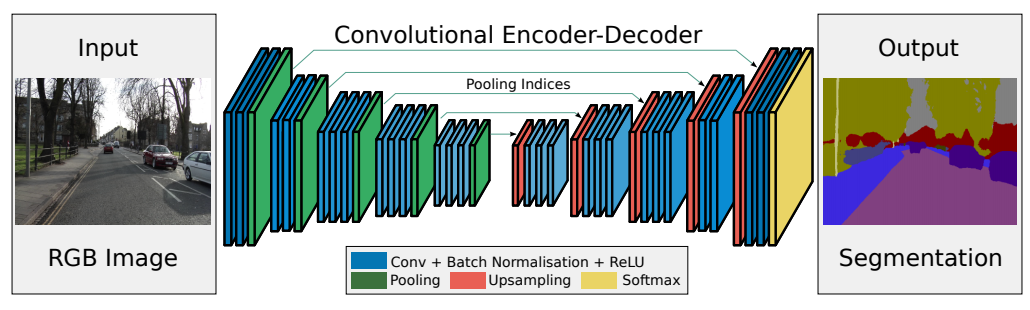

* Badrinarayanan, V., Kendall, A., & Cipolla, R. (2015). [SegNet: A deep convolutional
encoder-decoder architecture for image segmentation](https://arxiv.org/pdf/1511.00561.pdf)

Давайте разберемся как выглядит архитектура этой модели. Модель SegNet наследует архитектуру VGG16.


To be done:
- Рассмотреть два варианта upsamplig
- Рассмотреть два варианта написания SegNet, просто и через прописание классов EncoderBlock, DecoderBlock
- Посчитать на полном SegNet датасет со всеми 7ю лейблами
- Добавить тестовую выборку

Из статьи:

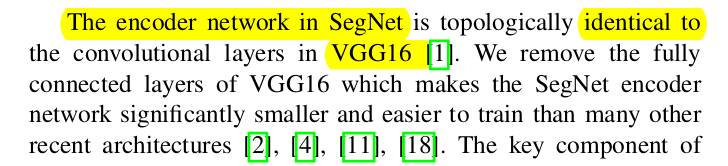

Давайте посмотрим как выглядит архитектура VGG16

In [ ]:
import torchvision.models as models

model_ft = models.vgg16(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 211MB/s]  


In [ ]:
model_ft

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [ ]:
class SegNet_Tiny(nn.Module):
    def __init__(self):
        super().__init__()

        # encoder (downsampling)
        self.enc_conv0 = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.pool0 = nn.MaxPool2d((2, 2))  # 256 -> 128
        self.enc_bn0 = nn.BatchNorm2d(num_features=8)
        self.enc_conv1 = nn.Conv2d(8, 8, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d((2, 2)) # 128 -> 64
        self.enc_bn1 = nn.BatchNorm2d(num_features=8)
        self.enc_conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d((2, 2)) # 64 -> 32
        self.enc_bn2 = nn.BatchNorm2d(num_features=16)

        # bottleneck
        #это как пересказать фильм одним предложением — ты вынужден выделить только самое важное. Боттлнек заставляет сеть сжать всю информацию в компактное представление, убрав лишнее.
        self.bottleneck_conv = nn.Conv2d(16, 16, kernel_size=1)

        # decoder (upsampling)
        self.upsample0 = nn.Upsample(scale_factor=2) # 32 -> 64
        self.dec_bn0 = nn.BatchNorm2d(num_features=32)
        # слой ConvTranspose2d c такими параметрами не меняет размер
        # карт активаций.
        self.dec_conv0 = nn.ConvTranspose2d(32, 8, 3, padding=1)
        self.upsample1 = nn.Upsample(scale_factor=2, mode = 'nearest')  # 64 -> 128 Когда метод не указан — по умолчанию используется nearest neighbor (ближайший сосед).
        self.dec_bn1 = nn.BatchNorm2d(num_features=16)
        self.dec_conv1 = nn.ConvTranspose2d(16, 8, 3, padding=1)
        self.upsample2 = nn.Upsample(scale_factor=2)  # 128 -> 256
        self.dec_bn2 = nn.BatchNorm2d(num_features=16)
        self.dec_conv2 = nn.ConvTranspose2d(16, 13, 3, padding=1)

    def forward(self, x):
        # encoder
        e0 = self.enc_bn0(self.pool0(F.relu(self.enc_conv0(x))))
        e1 = self.enc_bn1(self.pool1(F.relu(self.enc_conv1(e0))))
        e2 = self.enc_bn2(self.pool2(F.relu(self.enc_conv2(e1))))

        # bottleneck
        b = self.bottleneck_conv(e2)

        # decoder
        d0 = self.dec_conv0(self.dec_bn0(F.relu(self.upsample0(torch.cat([b, e2], 1)))))
        d1 = self.dec_conv1(self.dec_bn1(F.relu(self.upsample1(torch.cat([d0, e1], 1)))))
        d2 = self.dec_conv2(self.dec_bn2(F.relu(self.upsample2(torch.cat([d1, e0], 1)))))

        return d2

## Train

In [ ]:
import torch
from torchmetrics import JaccardIndex

from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import json

In [ ]:
def train_single_epoch(model, optimizer, criterion, train_dataloader, device):
    model.train()

    avg_loss = 0
    for X_batch, Y_batch in tqdm(train_dataloader):
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        Y_pred = model(X_batch)
        loss = criterion(Y_pred, Y_batch) # forward-pass

        loss.backward()  # backward-pass
        optimizer.step()  # update weights
        optimizer.zero_grad() # set parameter gradients to zero

        # calculate loss to show the user
        avg_loss += loss

    avg_loss = avg_loss/len(train_dataloader)

    return model, avg_loss

def validate_single_epoch(model, criterion, valid_dataloader, device, plot=False):

    iou_score = JaccardIndex(threshold=0.5, task="multiclass", num_classes=13, average='none').to(device)
    model.eval()

    avg_loss = 0
    avg_iou = 0
    with torch.no_grad():
      for X_batch, Y_batch in tqdm(valid_dataloader):
          X_batch = X_batch.to(device)
          Y_batch = Y_batch.to(device)

          Y_pred = model(X_batch)
          iou = iou_score(Y_pred, Y_batch)
          loss = criterion(Y_pred, Y_batch)
          avg_loss += loss
          avg_iou += iou

    avg_loss = avg_loss/len(valid_dataloader)
    avg_iou = avg_iou/len(valid_dataloader)

    if plot:
        clear_output(wait=True)
        our_labels = labels

        fig, axes = plt.subplots(1, 15, figsize=(15*4, 6*4)) #15, тк 13 классов и еще 1 оригинальное изображение и 1 маска

        orig_img = X_batch[0].permute(1,2,0).cpu().detach().numpy()
        orig_mask = Y_batch[0].cpu().detach().numpy()

        axes[0].imshow(orig_img);
        axes[0].set_title("Original Image")

        diagram = axes[1].imshow(Y_batch[0].cpu().detach().numpy(), interpolation='none')
        values = np.unique(Y_batch[0].cpu().detach().numpy())
        colors = [ diagram.cmap(diagram.norm(value)) for value in values]
        patches = [ mpatches.Patch(color=colors[i], label=f"{i} - {our_labels[i]}" ) for i in range(len(values)) ]
        axes[1].legend(handles=patches, bbox_to_anchor=(1.00, 1), loc=1, borderaxespad=0. )
        axes[1].set_title("Original Mask")

        for i in range(Y_pred.shape[1]):
            axes[2+i].imshow(Y_pred[0].cpu().detach().numpy()[i]>0.5)
            axes[2+i].set_title(f"{our_labels[i]}, iou = {'%.3f' % avg_iou[i]}")

        plt.show()

    return model, avg_loss, avg_iou

def train(model, optimizer, criterion, epochs, train_dataloader, valid_dataloader, device, ckpt_path, plot_loss=False, initial_stats=None):

    # если передали старую статистику — продолжаем с неё
    # если нет — начинаем с нуля
    if initial_stats is not None:
        total_train_loss = initial_stats['train_loss']
        total_val_loss = initial_stats['val_loss']
    else:
        total_train_loss = []
        total_val_loss = []

    total_val_iou = []

    best_val_loss = float('inf')
    best_val_iou = 0

    for epoch in tqdm(range(epochs)):

        model, train_loss = train_single_epoch(model, optimizer, criterion, train_dataloader, device)
        model, val_loss, val_iou = validate_single_epoch(model, criterion, valid_dataloader, device, plot=True)
        print(f'Epoch {epoch}: train loss = {train_loss}')
        print(f'Epoch {epoch}: val loss = {val_loss}')
        print(f'Epoch {epoch}: val iou = {val_iou}')

        total_train_loss.append(train_loss.cpu().detach().numpy())
        total_val_loss.append(val_loss.cpu().detach().numpy())
        total_val_iou.append(val_iou.cpu().detach().numpy())


        stats_to_save = {
            'train_loss': [float(x) for x in total_train_loss],
            'val_loss': [float(x) for x in total_val_loss],
        }
        with open(f'{ckpt_path}/statistics.json', 'w') as f:
            json.dump(stats_to_save, f)

        if plot_loss:
            fig, (ax1, ax2) = plt.subplots(1, 2)

            ax1.plot(list(range(len(total_train_loss))), total_train_loss, label = 'train loss')
            ax1.plot(list(range(len(total_val_loss))), total_val_loss, label = 'val loss')
            for i in range(len(val_iou)):
              ax2.plot(list(range(len(total_val_iou))), total_val_iou, label = f'val iou: {i}')
            ax1.set_title("Loss")
            ax2.set_title("IoU")
            ax1.legend()
            plt.show()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'{ckpt_path}/best_val_loss_model.pt')

        torch.save(model.state_dict(), f'{ckpt_path}/epoch_{epoch+6}_val_iou.pt')

    statistics = {'train loss': total_train_loss,
                  'val_loss': total_val_loss,
                  'val_iou': total_val_iou}

    return model, statistics

def test(model, test_dataloader, device, ckpt_path, ckpt_name):

    model.load_state_dict(torch.load(f'{ckpt_path}/{ckpt_name}')).to(device)
    model.eval()

    iou_score = JaccardIndex(threshold=0.5, task="binary", average='none').to(device)
    avg_iou = 0
    with torch.no_grad():
      for X_batch, Y_batch in test_dataloader:
          X_batch = X_batch.to(device)
          Y_batch = Y_batch.to(device)

          Y_pred = model(X_batch.to(device))
          avg_iou += iou_score(X_batch, Y_batch) # , threshold = 0.5)
      avg_iou = avg_iou / len(test_dataloader)

    return avg_iou

In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.7 MB/s eta 0:00:0000:01


In [ ]:
os.makedirs('/kaggle/working/checkpoints', exist_ok=True)

In [ ]:
import segmentation_models_pytorch as smp
model = SegNet_Tiny().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = smp.losses.DiceLoss(mode='multiclass')
epochs = 5
ckpt_path = '/kaggle/working/checkpoints'

In [ ]:
if os.path.exists('/kaggle/working/checkpoints'):
    print(os.listdir('/kaggle/working/checkpoints'))
else:
    print('Папка не найдена!')

['epoch_2_val_iou.pt', 'epoch_1_val_iou.pt', 'epoch_0_val_iou.pt', 'epoch_6_val_iou.pt', 'best_val_loss_model.pt', 'epoch_5_val_iou.pt', 'statistics.json', 'epoch_3_val_iou.pt', 'epoch_4_val_iou.pt']


In [ ]:
model = SegNet_Tiny().to(device)
model.load_state_dict(torch.load('/kaggle/working/checkpoints/epoch_6_val_iou.pt'))
print('Загружено!')

Загружено!


In [ ]:
import json

# загружаем старую статистику
with open('/kaggle/working/checkpoints/statistics.json', 'r') as f:
    old_stats = json.load(f)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.6784314].


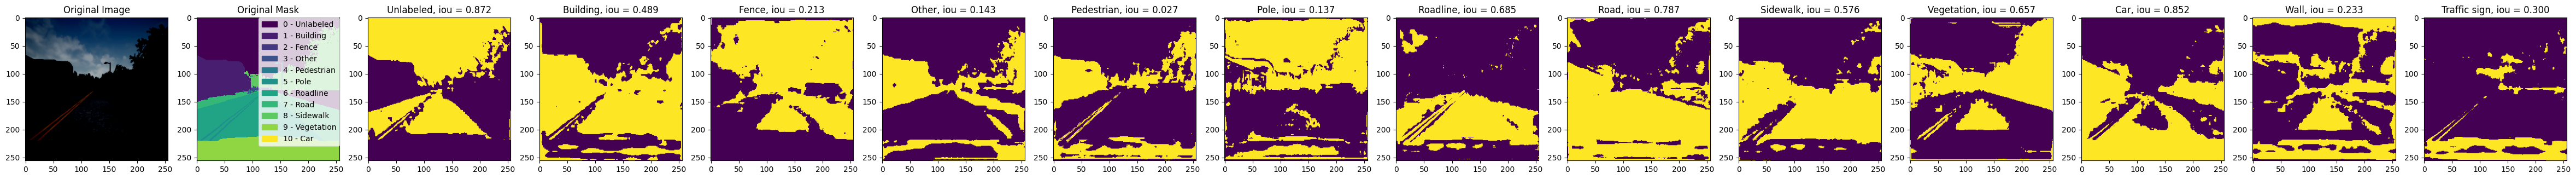

Epoch 4: train loss = 0.4295330345630646
Epoch 4: val loss = 0.43419861793518066
Epoch 4: val iou = tensor([0.8725, 0.4892, 0.2129, 0.1429, 0.0266, 0.1373, 0.6851, 0.7873, 0.5764,
        0.6566, 0.8522, 0.2327, 0.3005], device='cuda:0')


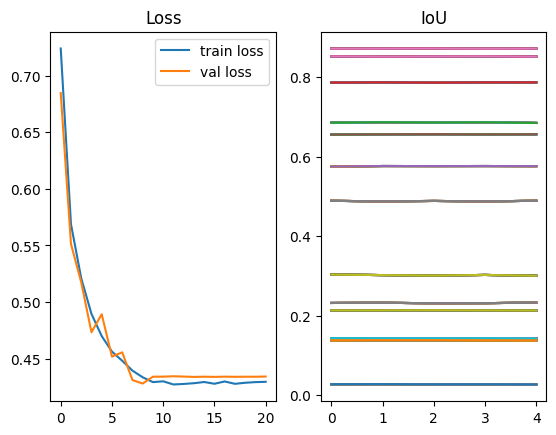

In [ ]:
model, statistics = train(model, optimizer, criterion, epochs, train_dataloader, valid_dataloader, device, ckpt_path, plot_loss=True, initial_stats=old_stats)

In [ ]:
import shutil

# копируем лучшую модель в корень output папки
shutil.copy('/kaggle/working/checkpoints/best_val_loss_model.pt',
            '/kaggle/working/best_val_loss_model.pt')
shutil.copy('/kaggle/working/checkpoints/statistics.json',
            '/kaggle/working/statistics.json')

'/kaggle/working/statistics.json'

Мы с вами создали и обучили простенькую нейросеть типа SegNet для сегментации картинок на 4 класса. Наша сеть работает не то чтобы отлично, и вы можете попытаться ее улучшить. Вот что можно сделать:

изменить количество слоев и/или их параметры. К примеру, в декодере мы использовали слои upsampling и transposed convolution, которые не увеличивали размер карт активации. На самом деле, может быть довольно полезно использовать слои transposed convolution, которые увеличивают размер карт активации. И тогда слои upsampling использовать будет уже не нужно.

часто делают так: используют слои transposed convolution, которые увеличивают размер карт активации, и между ними вставляют обычные слои convolution. Пример такого устройства сети можно посмотреть тут

сделать сеть по типу U-Net: добавить skip connections между слоями encoder и decoder;

обучить нейросеть с помощью другой лосс-функции. Например, Dice — это лосс-функция для задачи семантической сегментации.

In [6]:
import json

# Читаем текущий ноутбук
with open('/content/drive/MyDrive/DLS(1 part)/Lesson6(segmentation)/SematicSegmentation', 'r') as f:
    nb = json.load(f)

# Удаляем widgets из метаданных
if 'widgets' in nb['metadata']:
    del nb['metadata']['widgets']

# Сохраняем обратно
with open('/content/drive/MyDrive/DLS(1 part)/Lesson6(segmentation)/SematicSegmentation', 'w') as f:
    json.dump(nb, f)

print('Готово!')

Готово!


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
